# Projet COVID 19 : Modelisation Random Forest - 4 classes - Balanced - 1ère itération

## Conditions de modélisation

## Environnement de travail

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.inspection import permutation_importance
import joblib

In [7]:
# Répertoire du notebook
NOTEBOOK_DIR = Path.cwd()

# Racine du projet (Liora_Covid)
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent.parent

# Dossier des CSV
DATA_DIR = PROJECT_ROOT / "csv"

print("Notebook :", NOTEBOOK_DIR)
print("Projet   :", PROJECT_ROOT)
print("CSV      :", DATA_DIR)

Notebook : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\Liora_Covid\notebooks\Modelisation\Random Forest
Projet   : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\Liora_Covid
CSV      : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\Liora_Covid\csv


In [8]:
# Chargement des données
train = pd.read_csv(DATA_DIR / "train_features.csv")
validation = pd.read_csv(DATA_DIR / "validation_features.csv")
test = pd.read_csv(DATA_DIR / "test_features.csv")

print(f"\nTrain      : {train.shape}")
print(f"Validation : {validation.shape}")
print(f"Test       : {test.shape}")


Train      : (16668, 6)
Validation : (2083, 6)
Test       : (2084, 6)


## Définition de la cible et des features

In [9]:
target = "classe"

features = [
    "lum_interieur_masque",
    "lum_exterieur_masque",
    "surface_masque",
    "variance_laplacien"
]

target = "classe"

X_train = train[features]
y_train = train[target]

X_val = validation[features]
y_val = validation[target]

X_test = test[features]
y_test = test[target]

## Vérification des classes

In [10]:
print("Distribution train :")
print(y_train.value_counts(normalize=True))

print("\nDistribution validation :")
print(y_val.value_counts(normalize=True))

print("\nDistribution test :")
print(y_test.value_counts(normalize=True))

Distribution train :
classe
Normal             0.486501
Lung_Opacity       0.287437
COVID              0.161867
Viral Pneumonia    0.064195
Name: proportion, dtype: float64

Distribution validation :
classe
Normal             0.486318
Lung_Opacity       0.287086
COVID              0.162266
Viral Pneumonia    0.064330
Name: proportion, dtype: float64

Distribution test :
classe
Normal             0.486564
Lung_Opacity       0.287428
COVID              0.161708
Viral Pneumonia    0.064299
Name: proportion, dtype: float64


## Pipeline Random Forest

In [11]:
rf_pipe = Pipeline([
    ("model", RandomForestClassifier(
        random_state=0,
        class_weight="balanced",
        n_jobs=-1
    ))
])

## Grille des Hyperparamètres

In [14]:
param_grid_v2 = {
    "model__n_estimators": [200],
    "model__max_depth": [20, 30, 40, None],
    "model__min_samples_split": [10, 15, 20],
    "model__min_samples_leaf": [4, 6, 8],
    "model__max_features": ["sqrt"]
}

## Cross-validation stratifiée + GridSearch

In [15]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

grid_rf = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_v2,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_rf.fit(X_train, y_train)


Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_jobs=-1,
                                                               random_state=0))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [20, 30, 40, None],
                         'model__max_features': ['sqrt'],
                         'model__min_samples_leaf': [4, 6, 8],
                         'model__min_samples_split': [10, 15, 20],
                         'model__n_estimators': [200]},
             return_train_score=True, scoring='f1_macro', verbose=1)

In [16]:
# Meilleurs paramètres

print("Meilleurs paramètres :")
print(grid_rf.best_params_)

print("\nMeilleur score F1 moyen en cross-validation :")
print(grid_rf.best_score_)

Meilleurs paramètres :
{'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 15, 'model__n_estimators': 200}

Meilleur score F1 moyen en cross-validation :
0.4772621698410144


In [17]:
# Résultats de la GridSearch

results = pd.DataFrame(grid_rf.cv_results_)
results = results.sort_values("rank_test_score")

results[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "params"
]].head(10)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,params
1,1,0.477262,0.009253,0.771552,0.003490,"{'model__max_depth': 20, 'model__max_features'..."
0,2,0.476660,0.010115,0.821536,0.004553,"{'model__max_depth': 20, 'model__max_features'..."
10,3,0.476226,0.008323,0.779233,0.003708,"{'model__max_depth': 30, 'model__max_features'..."
19,4,0.475774,0.008305,0.779066,0.003522,"{'model__max_depth': 40, 'model__max_features'..."
28,4,0.475774,0.008305,0.779066,0.003522,"{'model__max_depth': None, 'model__max_feature..."
13,6,0.475231,0.010664,0.748959,0.001767,"{'model__max_depth': 30, 'model__max_features'..."
22,7,0.475227,0.010785,0.748914,0.001897,"{'model__max_depth': 40, 'model__max_features'..."
31,7,0.475227,0.010785,0.748914,0.001897,"{'model__max_depth': None, 'model__max_feature..."
4,9,0.474603,0.011907,0.744091,0.002483,"{'model__max_depth': 20, 'model__max_features'..."
23,10,0.473801,0.008661,0.715074,0.002016,"{'model__max_depth': 40, 'model__max_features'..."


## Évaluation sur validation

### Classification report

In [18]:
best_rf = grid_rf.best_estimator_

y_val_pred = best_rf.predict(X_val)
y_val_proba = best_rf.predict_proba(X_val)

print("Évaluation sur le jeu de validation")
print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Balanced accuracy :", balanced_accuracy_score(y_val, y_val_pred))
print("Precision macro :", precision_score(y_val, y_val_pred, average="macro"))
print("Recall macro :", recall_score(y_val, y_val_pred, average="macro"))
print("F1-score macro :", f1_score(y_val, y_val_pred, average="macro"))
print("F1-score weighted :", f1_score(y_val, y_val_pred, average="weighted"))

print("\nRapport de classification :")
print(classification_report(y_val, y_val_pred))

Évaluation sur le jeu de validation
Accuracy : 0.5626500240038406
Balanced accuracy : 0.4891341324554632
Precision macro : 0.45482965034706835
Recall macro : 0.4891341324554632
F1-score macro : 0.4641777272290792
F1-score weighted : 0.5550205510765818

Rapport de classification :
                 precision    recall  f1-score   support

          COVID       0.25      0.17      0.20       338
   Lung_Opacity       0.54      0.56      0.55       598
         Normal       0.69      0.70      0.69      1013
Viral Pneumonia       0.33      0.53      0.41       134

       accuracy                           0.56      2083
      macro avg       0.45      0.49      0.46      2083
   weighted avg       0.55      0.56      0.56      2083



### Matrice de confusion

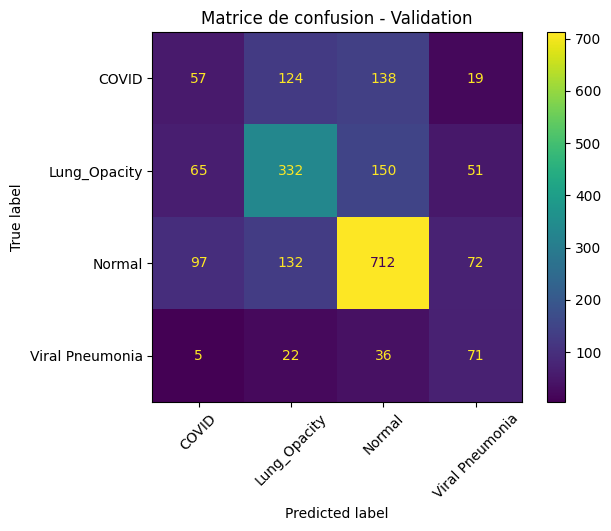

In [21]:
cm = confusion_matrix(y_val, y_val_pred)
class_names = best_rf.named_steps["model"].classes_

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion - Validation")
plt.show()

### Features importance

In [22]:
rf_model = best_rf.named_steps["model"]

importances = rf_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
0,lum_interieur_masque,0.355198
3,variance_laplacien,0.298962
2,surface_masque,0.194325
1,lum_exterieur_masque,0.151515


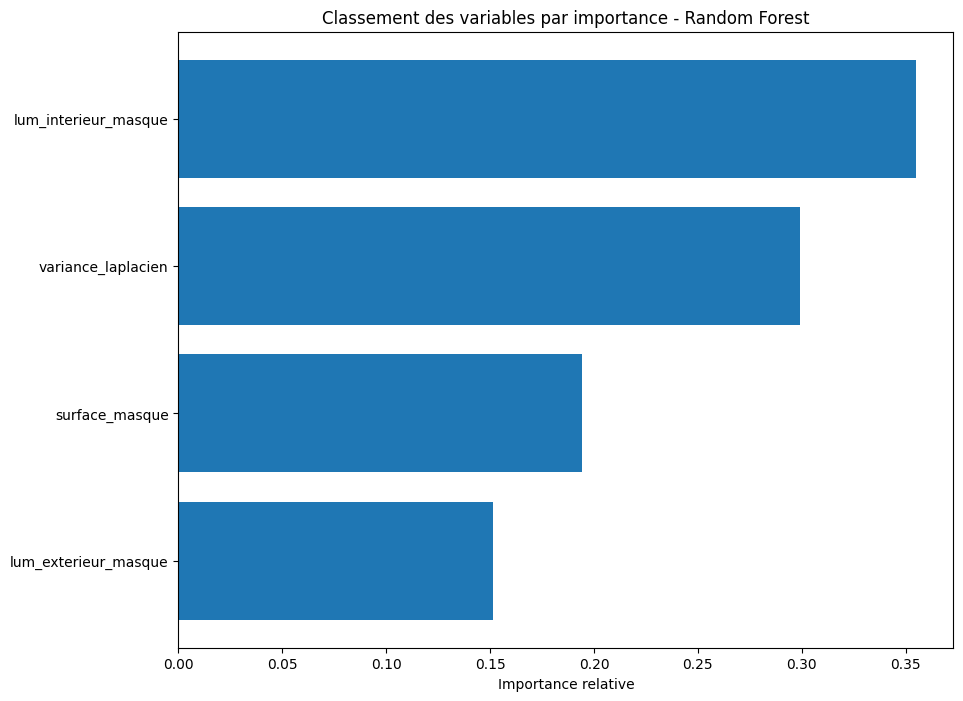

In [23]:
plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance_df["feature"][::-1],
    feature_importance_df["importance"][::-1]
)
plt.xlabel("Importance relative")
plt.title("Classement des variables par importance - Random Forest")
plt.show()

### Permutation importance

In [27]:
perm_importance = permutation_importance(
    best_rf,
    X_val,
    y_val,
    scoring="f1_macro",
    n_repeats=10,
    random_state=0,
    n_jobs=-1
)

In [28]:
perm_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
})

perm_df = perm_df.sort_values(
    by="importance_mean",
    ascending=False
).reset_index(drop=True)

perm_df.head(20)

,feature,importance_mean,importance_std
0,variance_laplacien,0.154009,0.011674
1,lum_interieur_masque,0.091754,0.007556
2,surface_masque,0.058213,0.007454
3,lum_exterieur_masque,0.008156,0.006685


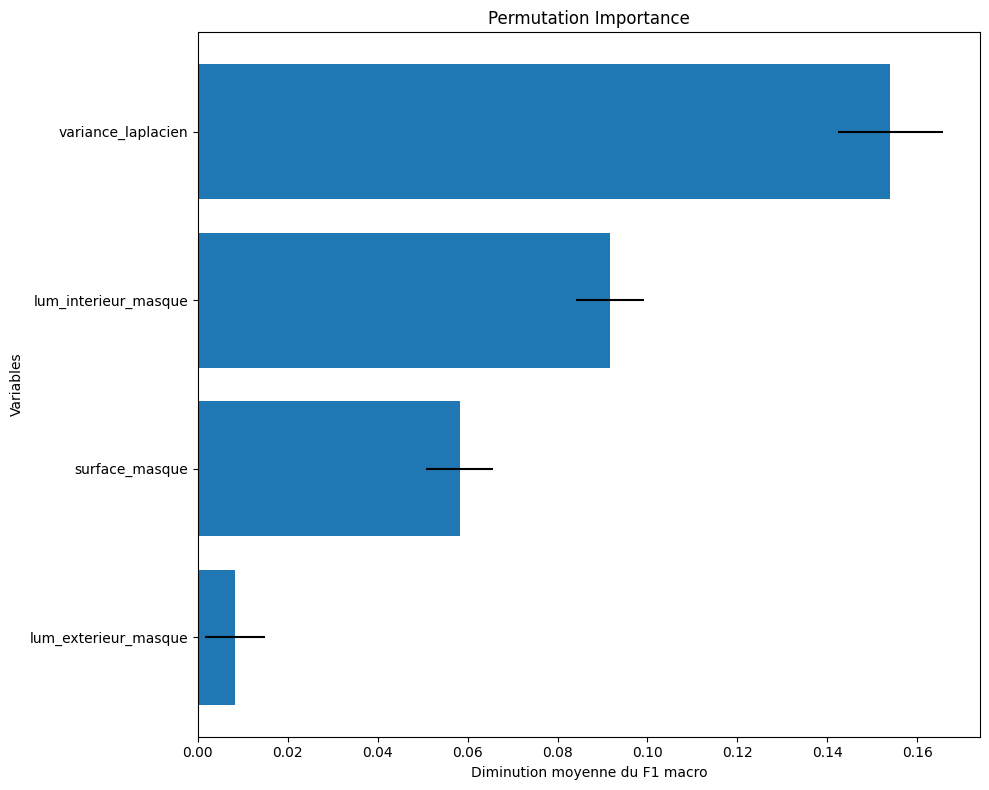

In [29]:
plt.figure(figsize=(10,8))

plt.barh(
    perm_df["feature"][:20][::-1],
    perm_df["importance_mean"][:20][::-1],
    xerr=perm_df["importance_std"][:20][::-1]
)

plt.xlabel("Diminution moyenne du F1 macro")
plt.ylabel("Variables")
plt.title("Permutation Importance")

plt.tight_layout()
plt.show()